# Lesson 198 · Three research directions

Complete proposal/evidence audit with full original input packet. CPU only; no model training or inference. Your three functions control the proposal matrices and decisions. Author examples are not learner submissions.

In [1]:
# @colab-bootstrap
import ast, base64, hashlib, io, itertools, json, math, os, subprocess, sys, tempfile, zipfile, importlib.util
from pathlib import Path
needed = ['numpy==2.5.0', 'scipy==1.18.0', 'beautifulsoup4==4.15.0']
if any(importlib.util.find_spec(m) is None for m in ["numpy","scipy","bs4"]):
    subprocess.run([sys.executable,"-m","pip","install","-q",*needed],check=True,timeout=300)
import numpy as np
workspace=Path(tempfile.mkdtemp(prefix="l198-proposals-"))

<p class="eyebrow">Year 5 · Research proposals · Lesson 198</p>

# Three directions worth trying to disprove

**Your win:** turn the landscape essay into three ranked research proposals that a skeptical collaborator could assess. Each proposal must say what changes, what stays fixed, what would count against it, and what must be resolved before running it. Work through the core in about 20 minutes, then spend a separate session drafting your cards and completing the lab.

The mission is to test whether learned relational models add value beyond strong tabular approaches. A useful negative result also advances that mission: it tells us where a more complicated model is unnecessary.

[Lesson 189](https://avistian.github.io/relational/lessons/0189-identify-open-problems.html) collected candidate gaps. [Lesson 197](https://avistian.github.io/relational/lessons/0197-year-5-essay.html) separated a defensible claim from its evidence. **The new step here is experimental commitment:** turn each gap into a complete comparison and an explicit decision rule. [Lesson 199](https://avistian.github.io/relational/lessons/0199-select-primary-direction.html) supplies the method for choosing a primary direction; the ranking here remains provisional.

<div class="evidence-status"><strong>Author audit: COMPLETE_SELECTED_PROPOSAL_AUDIT.</strong> All three proposals, all 27 ranking settings and the complete L197 evidence packet replayed. New model experiments: <code>NOT_RUN</code>. Novelty: <code>NOT_ESTABLISHED</code>. Your defense: <code>PENDING_WRITTEN_DEFENSE</code>.</div>





**Prerequisite recap.** A *query* is an entity at a prediction time. Its label may describe an outcome during a later window. *Availability* asks whether an input was actually knowable then. A *baseline* is the comparison method under the same information and selection rules. *Pretraining* learns from source tasks before the target task. A *prior* is the distribution of tasks used to teach a foundation predictor. An *encoder* turns rows and relationships into representations used by that predictor.

*AUROC* measures how often a positive example ranks above a negative one, with half credit for ties. It ranges from 0 to 1; higher is better. Here 0.01 means one AUROC percentage point. The proposed margin is a planning choice, not a universal standard of practical importance.

## 1 · A topic is not yet a contribution

“Use graph structure” names an interest. A proposal needs five connected statements:

1. **Known result:** what the nearest work already establishes.
2. **Candidate contribution:** the specific unanswered comparison.
3. **Hypothesis:** the change you predict in a defined population.
4. **Experiment:** intervention, matched control, complete run matrix and scoring rule.
5. **Decision:** a result that supports, weakens or leaves the hypothesis unresolved.

> **In plain terms.** Give someone who disagrees with you a fair way to prove your idea unhelpful.

**Worked narrowing.** “Temporal pretraining helps” is already studied. The [temporal-pretraining paper, §4.4](https://arxiv.org/html/2609.35219v1#S4.SS4), leaves unseen-database transfer and matched computational cost open. Narrow the proposal to those conditions. [Relational Transformer](https://arxiv.org/html/2510.06377v1) already studies transfer across relational data, so “cross-database” alone is not the novelty argument.

**Novelty is a comparison with the nearest work.** Read methods and limitations, not just titles. Write down which axis differs: population, information policy, operator, objective, comparator or evaluation. If the closest work answers the same question under the same conditions, revise or retire the proposal.

> **Scope check.** The six frozen primary texts are selected evidence, not an exhaustive review. Two additional abstract-level leads—[Curriculum Matters](https://arxiv.org/abs/2607.29120) and [PluRel-to-RDB-PFN](https://arxiv.org/abs/2607.29129)—make broad claims about “new synthetic relational pretraining” particularly unsafe. Their results are not reproduced here. Novelty remains `NOT_ESTABLISHED` for all three proposals.

## 2 · Direction one: do availability assumptions change the comparison?

**Question.** On `rel-f1/driver-dnf` and `rel-trial/study-outcome`, does the RDB-PFN versus flattened-tree contrast change when timestamp filtering is replaced by an explicit availability policy?

A timestamp records an event time. An availability policy records when an input can be used. These may differ: an outcome whose window ends next month is not known merely because its row begins today. If true arrival times are unavailable, state the assumptions you vary. Do not call an assumption-driven difference proof of historical leakage.

**Hold fixed:** full query identities, targets, data release, model settings, validation-only selection, and the paired labeled-support schedule. Both models receive the same permissible labeled information within a policy. Only the eligibility policy changes. If that contract cannot be maintained, stop before running models.

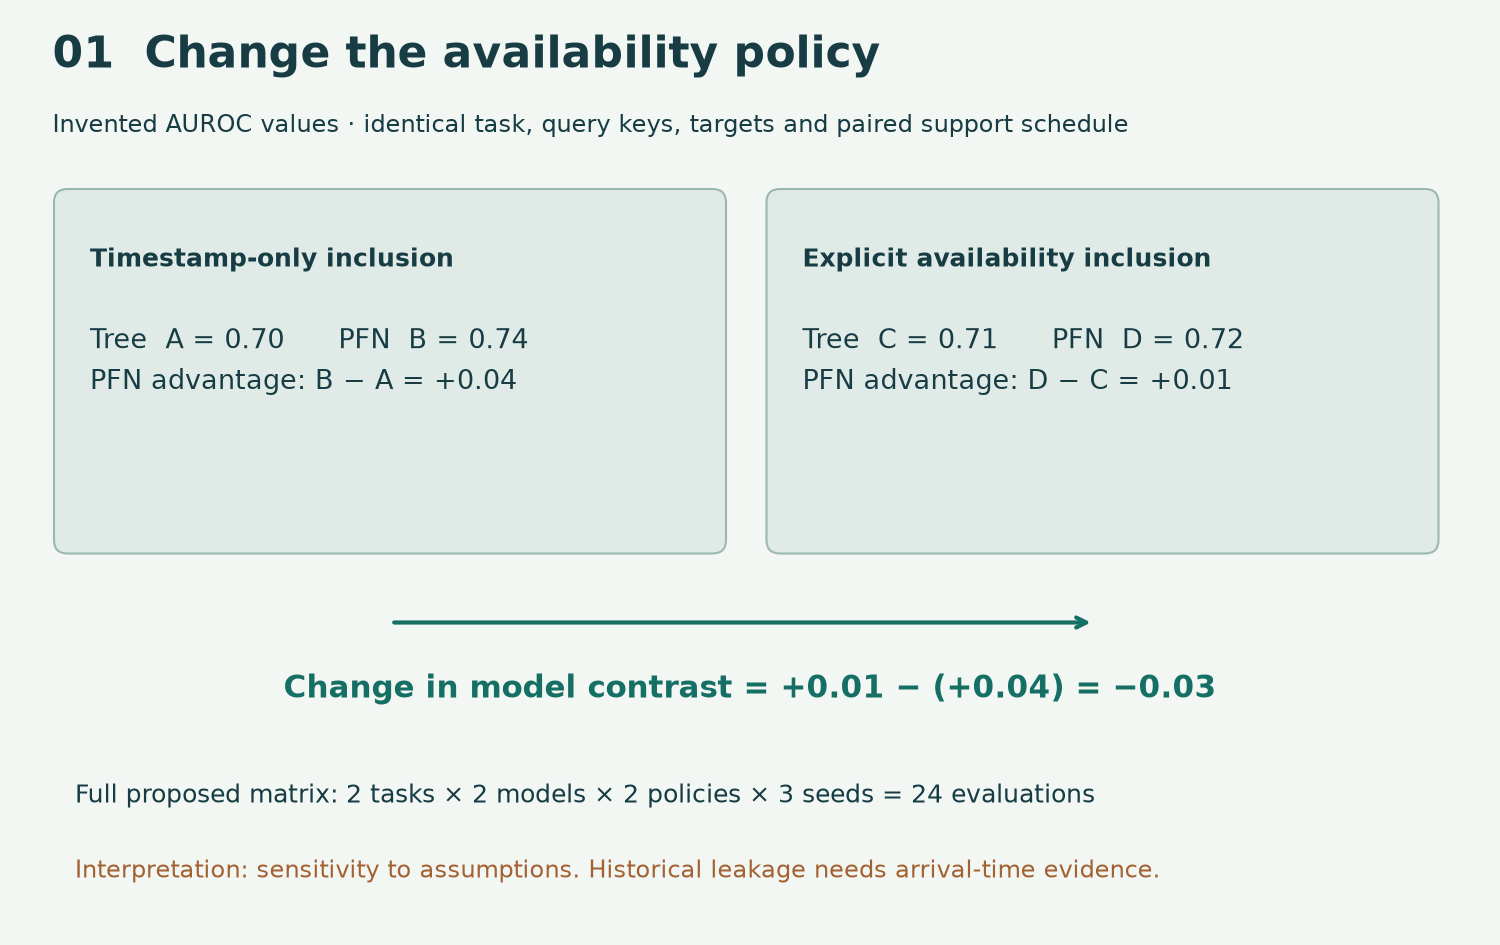

*Invented scores isolate the change in a model contrast. Query identities and labeled information stay paired.*

**Worked example — invented AUROC values.** Under timestamp filtering, tree = 0.70 and PFN = 0.74: PFN advantage = 0.04. Under the availability policy, tree = 0.71 and PFN = 0.72: advantage = 0.01. The policy changes the advantage by **0.01 − 0.04 = −0.03**. This is a *difference of differences*: one model contrast minus the corresponding contrast under another condition.

**What would refute material sensitivity?** A justified interval wholly inside (−0.01, +0.01). An interval wholly above +0.01 or below −0.01 supports a material change. Crossing or touching a boundary is inconclusive under our conservative teaching rule. The uncertainty procedure is still an execution-protocol requirement; the picture does not supply one.

**Apply the rule at the boundary.** Keep the illustrative sensitivity margin fixed at 0.01 and vary only an externally justified interval for the policy contrast:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Interval</th><th>Decision</th><th>Reason</th></tr></thead><tbody><tr><td>[−0.009, +0.009]</td><td>Below useful margin</td><td>Strictly inside the band</td></tr><tr><td>[−0.010, +0.009]</td><td>Inconclusive</td><td>Touches a boundary</td></tr><tr><td>[+0.011, +0.020]</td><td>Material sensitivity</td><td>Strictly above +0.010</td></tr></tbody></table>

These are hypothetical inputs to `interval_decision`, not uncertainty estimates for the proposed experiment. The function applies a declared rule; it cannot justify how the interval was estimated. Preserve sufficient numerical precision before checking the boundary: a rounded display is not the decision input.

**Transfer the trace.** Change only the last interval's lower endpoint to +0.010. The decision becomes inconclusive, despite the positive mean you might imagine inside it. This lesson deliberately uses strict boundaries; do not import the inclusive numerical-parity gates used elsewhere in the course.


[RelArena](https://arxiv.org/html/2608.16319v2) already provides standardized relational comparisons. The candidate contribution is a measured sensitivity study with documented information assumptions, not benchmarking itself or fixing one cache key.

## 3 · Direction two: separate the prior from the encoder

**Question.** Does composite message passing add a useful benefit under a relational prior, and is that benefit larger than under a single-table prior?

[RelGNN](https://arxiv.org/html/2502.06784v2) already introduces composite message passing. [RDB-PFN](https://arxiv.org/html/2603.03805v5) already learns from synthetic relational tasks and uses DFS-derived features. Here *DFS* means deep feature synthesis: constructing flat features by aggregating related rows. Changing the synthetic generator changes the learning experience; changing the encoder changes the predictor. Changing both at once hides which change mattered.

**A factorial design crosses two interventions.** Train every combination of two priors and two encoders. Keep the prediction head, labeled supports, permissible path endpoints, selection budget and compute accounting matched. A conventional two-hop encoder must see the same reachable information. The proposed graph encoder and ICL head need training from compatible initialization; fitting an embedding width does not make a released checkpoint valid.


<noscript><p>Predict: does a positive composite gain under the relational prior guarantee positive interaction? No; its gain may be larger under the other prior.</p></noscript>

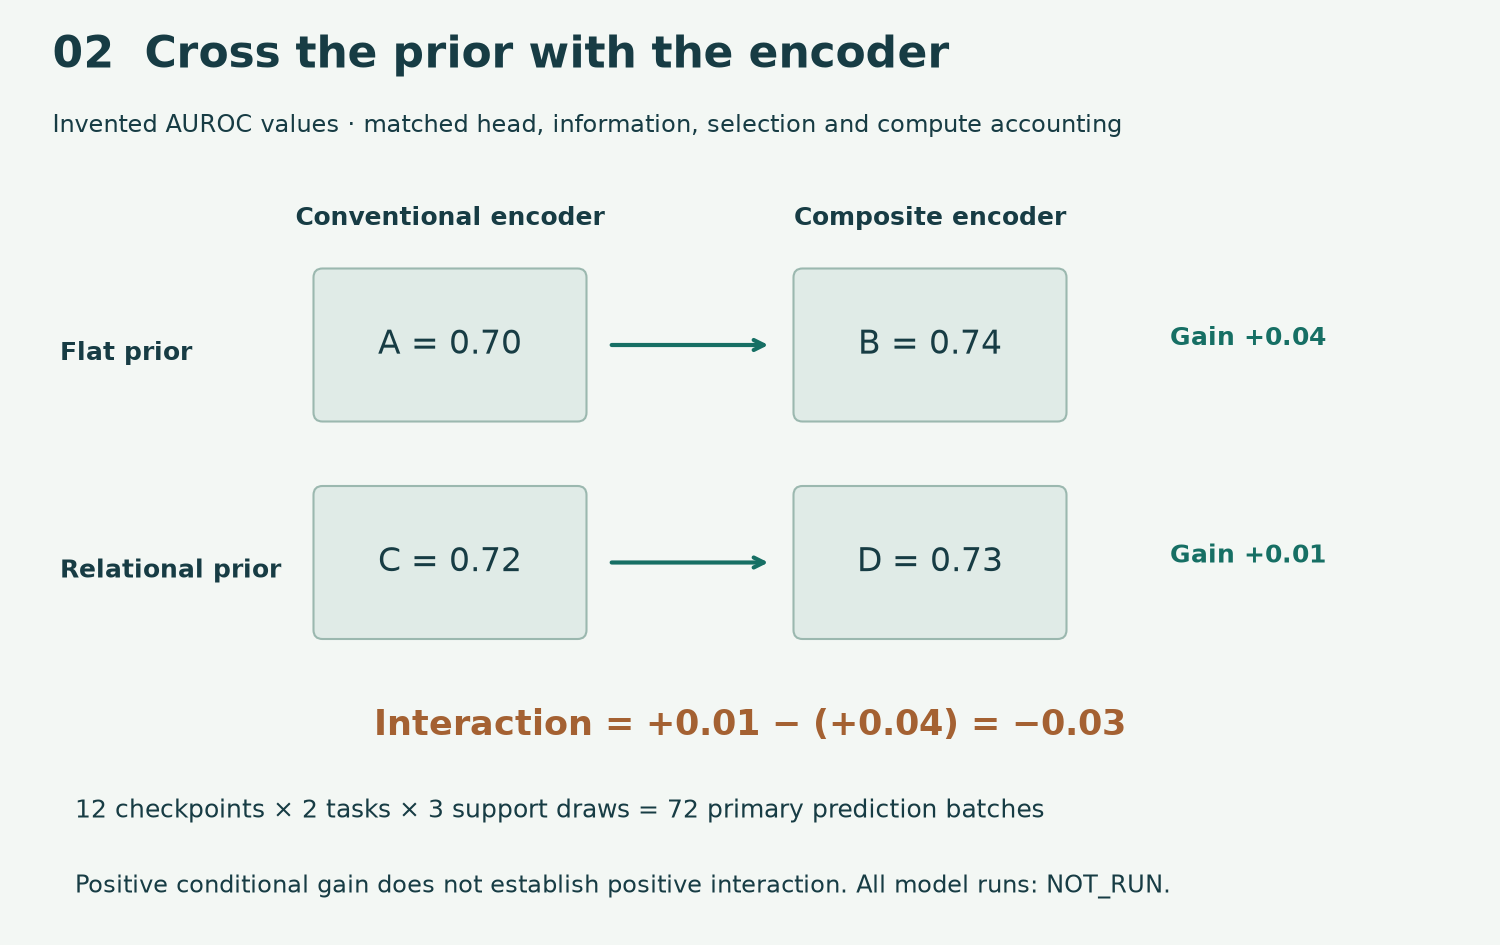

*Invented scores show positive conditional gains but negative interaction. The full proposed evaluation counts all support draws.*

**Worked example — invented AUROC values.** The composite gain is 0.74 − 0.70 = 0.04 under the flat prior and 0.73 − 0.72 = 0.01 under the relational prior. The *interaction* is **0.01 − 0.04 = −0.03**. Composite helps both, but this example does not support extra benefit from combining it with the relational prior.

Two questions therefore remain separate: is the relational-prior conditional gain usefully positive, and is the interaction positive? A positive interaction alone is insufficient if both encoders perform worse. Show all four absolute scores and both contrasts.

**Complete accounting.** Two priors × two encoders × three initialization seeds gives 12 checkpoints. Evaluate each on two tasks and three support draws: **72 primary prediction batches**, corresponding to 24 checkpoint/task combinations. Add six released-checkpoint comparator batches and 18 tree fits/batches. A *support draw* chooses labeled examples for in-context prediction; it is not another independent database. These units count different operations and must be costed separately.

## 4 · Direction three: does pretraining beat spending the budget on the target?

**Question.** Do historical-relation or future-activity objectives improve a wholly held-out database beyond an equally expensive supervised baseline?

A *historical-relation objective* learns to recover eligible past links. A *future-activity objective* learns outcomes over a later window using only source examples whose label windows are complete. A *database holdout* excludes the entire target database from source training and source preprocessing. Excluding target labels alone is insufficient.

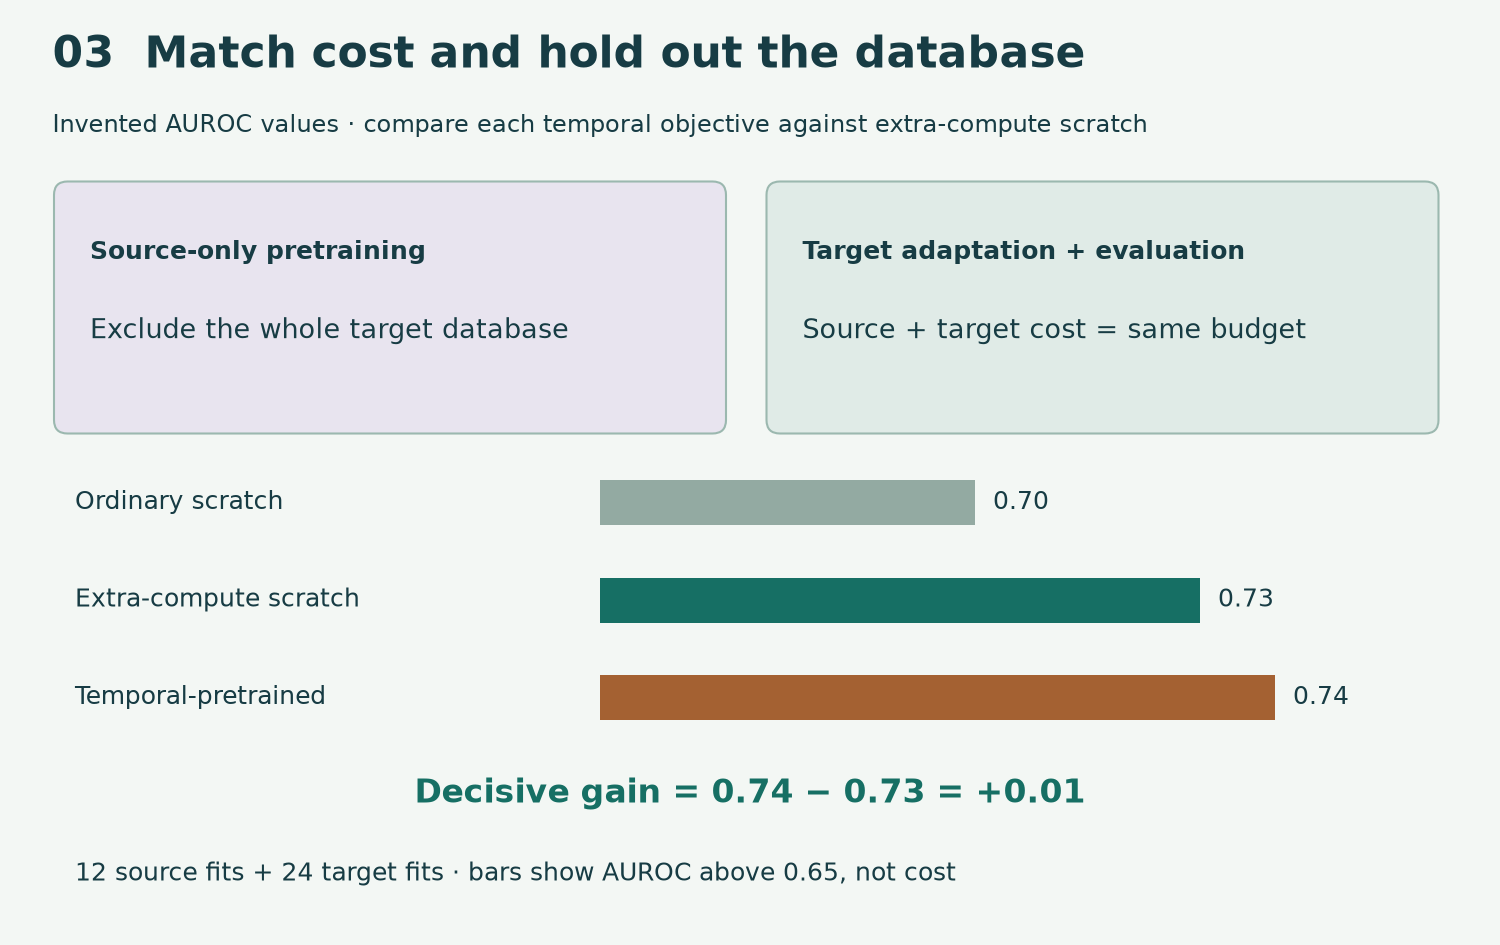

*Invented scores show why extra-compute scratch is the decisive control. The target database is excluded from source preprocessing and training.*

**Worked example — invented AUROC values.** Ordinary scratch training scores 0.70. Extra-compute scratch scores 0.73. A pretrained arm scores 0.74. Its apparent 0.04 gain over ordinary scratch becomes **0.01 over the decisive control**. Source training, adaptation, preprocessing and selection all belong in the total budget. Equal update counts do not guarantee equal computational cost.

**Complete accounting.** Two held-out databases × two objectives × three seeds requires 12 source fits. Two target tasks × four arms × three seeds requires 24 target fits. The four arms are scratch, extra-compute scratch, historical-pretrained and future-pretrained. Report each objective/task separately; freeze any multiple-comparison policy before seeing outcomes.

An upper uncertainty bound below the proposed +0.01 useful-gain margin rules out that useful benefit in the declared setting. An interval crossing the margin remains inconclusive. A failed exclusion or cost audit invalidates the comparison before statistical interpretation. Two databases still form a narrow study.

## 5 · Decide what an interval actually says

An *estimand* is the quantity the experiment intends to estimate: here a paired gain or difference of differences. An *interval* describes uncertainty under a specified procedure and sampling unit. A sampling unit might be a driver or a database; choosing it incorrectly can make certainty misleading.

> **In plain terms.** First decide what would matter. Then ask whether the evidence is precise enough to distinguish it from what would not matter.


<noscript><p>Illustrative gain interval [−0.005, 0.025], useful margin 0.01: INCONCLUSIVE. Illustrative sensitivity interval [−0.005, 0.005]: BELOW_USEFUL_MARGIN. These are invented intervals, not fitted results.</p></noscript>

The explorer classifies supplied intervals; it does not estimate them. For the future studies, specify paired resampling, dependency groups, confidence level and multiplicity before execution. Do not treat three seeds as three databases. L197's driver bootstrap belongs to its original regression comparison and cannot be borrowed as the uncertainty model for these new tasks.

## 6 · Rank the next useful decision, not a promised breakthrough

Impact means how much answering the question could change a research decision, including a negative answer. Feasibility concerns the **next informative step**, scored separately for data access, implementation and compute. These are authored judgments on a 1–5 scale, not measured probabilities.

The existing rubric is **impact × weighted mean feasibility**. With equal weights, temporal = 4 × (5+4+5)/3 = 18.67; composite = 5 × (4+3+2)/3 = 15; transfer = 5 × (3+2+1)/3 = 10.


<noscript><p>Default priority: temporal 18.67, composite 15, transfer 10. Reduce temporal impact from 4 to 3: temporal becomes 14 and composite leads. All full-run cost bounds remain unverified.</p></noscript>

All 27 weight triples from {1,2,3}³ retain temporal as the leader at the original scores. This does not establish robustness to every assumption: reducing temporal impact to 3 changes the equal-weight leader to composite. Ties must remain ties.

**Why these scores?** Temporal uses existing local audit paths, although arrival history remains uncertain. Composite needs a new trainable interface and twelve pretrained checkpoints. Transfer also needs a source corpus and auditable whole-database exclusions. The complete cards record the original rationale and preparation-effort estimates; these are estimates, not measured runtimes.

**Priority does not establish affordability.** Include preparation, training, selection, evaluation, retries and validation. Every full experiment currently has unknown phases, so all remain `NOT_ESTABLISHED` against the standing $10 cap. Unknown expense is not zero. L198 itself executes only the approved $0 proposal/evidence audit.

## 7 · Inspect the complete proposal cards

Each card preserves its original evidence, explains what the later lessons add, and lists exact execution gaps. A complete proposal can honestly contain unresolved implementation details. That makes it reviewable, not ready to dispatch.

### Temporal-policy sensitivity

**Question.** Across rel-f1/driver-dnf and rel-trial/study-outcome, does replacing timestamp-only filtering with an explicit availability contract change paired model contrasts?

**What is already known.** Chronological evaluation and temporal-aware models already exist. L184 reports repeated-entity cache collisions in one source snapshot. L169 context curves do not measure pretraining scaling.

**Candidate contribution.** The new contribution would be a measured change in matched model contrasts under declared availability policies, not the discovery of temporal filtering or a cache repair.

**What L197 adds and leaves open.** L197 provides a complete saved evidence inventory; it contains no results for these two availability policies. L196 shows why a source diagnostic alone cannot estimate accuracy harm.

**Refined hypothesis.** On each declared task, the absolute policy-induced change in the RDB-PFN minus tree AUROC contrast exceeds 0.01.

**Matched controls.** Same cached data release, targets, splits, feature definitions and validation-only selection for RDB-PFN and a flattened tree baseline; two visibility policies. Reuse identical support rows and seeds across policies, with any ineligible support reported before running.

**Estimand.** For each task and seed, compute (AUROC_PFN − AUROC_tree)_strict − (AUROC_PFN − AUROC_tree)_timestamp. Report each task separately; seed spread is not database uncertainty.

**Falsifier.** A justified paired interval strictly inside (-0.01, 0.01) rules out the proposed material change for that task. Entirely beyond either margin supports sensitivity. All boundary-crossing or boundary-touching intervals remain inconclusive.

**Complete accounting.** 24 model/policy/task/seed evaluations, each on complete validation and test populations. RDB-PFN is checkpoint inference; tree arms require fitting. Seed pairs share a frozen support schedule; all models use the same eligible labeled information within each policy.

**Cheapest next artifact.** Availability ledger for all query and feature identities, distinguishing known, assumed and unknown observation times.

**Declared matrix.** Every combination is listed in the machine-readable report; each axis below is frozen as a proposal.

- model evaluations: task ∈ {rel-f1/driver-dnf, rel-trial/study-outcome} × model ∈ {RDB-PFN, flattened-tree} × policy ∈ {timestamp, availability} × seed ∈ {0, 1, 2} = **24**.

**Unresolved before execution:**

- Exact source/data hashes and target reconstruction
- Full (entity_id, cutoff) train/validation/test manifests
- One validation-only selection rule and fixed search budget
- Per-task uncertainty resampling unit and coverage rationale
- Timed all-in cost bound including retries and validation
- Availability lineage for every feature and support label; historical arrival times may be unavailable
- Exact tree config, PFN checkpoint and shared label-budget/support policy
- Stop if paired eligible supports cannot be maintained; do not silently drop queries

**Original priority rationale:**

- Data 5: local full-key snapshots and audit receipts exist; actual historical arrival times remain unknown.
- Implementation 4: policy masks and keyed scoring are bounded; full DFS availability lineage still needs audit.
- Compute 5: first useful decision is a CPU key/availability audit, not new pretraining; complete model comparison cost is unverified.

**Preparation effort:** 8–16 human hours (authored planning estimate). All six full-run cost phases are unknown; budget NOT_ESTABLISHED.

**Closest work:** [survey](https://arxiv.org/html/2506.16654v1), [relarena](https://arxiv.org/html/2608.16319v2), [temporal](https://arxiv.org/html/2609.35219v1).

**Original receipts (reports only):** [l184-report.json](https://avistian.github.io/relational/labs/evidence/l198/packet/evidence/l189/packet/inherited/l184-report.json), [l169-report.json](https://avistian.github.io/relational/labs/evidence/l198/packet/evidence/l189/packet/inherited/l169-report.json), [l177-report.json](https://avistian.github.io/relational/labs/evidence/l198/packet/evidence/l189/packet/inherited/l177-report.json). These receipts are authenticated; their raw experiments are not all replayed. The full L197 packet is replayed separately.

**State:** PROPOSAL_NOT_EXECUTION_READY; models NOT_RUN; novelty NOT_ESTABLISHED; learner PENDING_WRITTEN_DEFENSE.


### Prior × encoder interaction

**Question.** Does a composite encoder improve a schema-shared graph encoder plus ICL head beyond a conventional two-hop encoder when priors, labels, information and total compute are matched?

**What is already known.** RelGNN already contributes composite message passing. RDB-PFN uses synthetic relational priors and DFS before its predictor. L182 re-evaluates released predictors, not a trained composite hybrid.

**Candidate contribution.** Isolate the predictor-side composite operator and its interaction with a relational prior. RelGNN already supplies the operator, and RDB-PFN already supplies relational synthetic pretraining.

**What L197 adds and leaves open.** L197 replays a small released-system advantage on study-outcome; that is neither a trained hybrid nor evidence that changing the encoder causes the advantage.

**Refined hypothesis.** The composite encoder gives a useful (>0.01 AUROC) conditional gain under the relational prior, and its gain exceeds its gain under the single-table prior.

**Matched controls.** Four factorial arms share task counts, hidden width/parameter accounting, optimizer/selection budgets, schema-sharing rules, labeled supports and permissible neighbors. Conventional two-hop control sees the same path endpoints. Add a flattened strong baseline before interpreting practical value.

**Estimand.** Within each task/seed, (composite_relational − conventional_relational) − (composite_flat − conventional_flat). Also report composite_relational − conventional_relational. A positive interaction alone is insufficient if both architectures get worse.

**Falsifier.** For useful benefit, an upper interval endpoint below 0.01 rules out the proposed gain; a lower endpoint above 0.01 supports it. Separately test synergy against zero: an upper interaction endpoint ≤0 fails the positive-interaction claim. Uncertain or boundary-touching benefit intervals remain inconclusive.

**Complete accounting.** 12 new checkpoints; 24 checkpoint/task combinations × 3 support draws = 72 primary batches. Also 6 frozen-checkpoint comparator batches and 18 tree fits/batches. Each batch scores the complete declared validation and test populations. Counts name different units and must not be summed as identical training jobs.

**Cheapest next artifact.** Written tensor/interface contract and an explicitly proposed finite-gradient probe, followed by a complete training cost forecast. The probe itself is not run in L198.

**Declared matrix.** Every combination is listed in the machine-readable report; each axis below is frozen as a proposal.

- pretraining checkpoints: prior ∈ {single-table, relational} × encoder ∈ {conventional, composite} × seed ∈ {0, 1, 2} = **12**.
- primary prediction batches: prior ∈ {single-table, relational} × encoder ∈ {conventional, composite} × seed ∈ {0, 1, 2} × task ∈ {rel-f1/driver-dnf, rel-trial/study-outcome} × support_draw ∈ {0, 1, 2} = **72**.
- released prediction batches: model ∈ {released-DFS-RDB-PFN} × task ∈ {rel-f1/driver-dnf, rel-trial/study-outcome} × support_draw ∈ {0, 1, 2} = **6**.
- tree fit prediction batches: model ∈ {flattened-tree} × task ∈ {rel-f1/driver-dnf, rel-trial/study-outcome} × seed ∈ {0, 1, 2} × support_draw ∈ {0, 1, 2} = **18**.

**Unresolved before execution:**

- Exact source/data hashes and target reconstruction
- Full (entity_id, cutoff) train/validation/test manifests
- One validation-only selection rule and fixed search budget
- Per-task uncertainty resampling unit and coverage rationale
- Timed all-in cost bound including retries and validation
- Trainable graph/head interface, finite gradients and compatible initialization
- Exact generator/source exclusions, task curriculum, schedules and parameter/compute matching
- Meaningful same-shape control for single-table prior; do not change both graph access and encoder capacity
- Separate task/initialization uncertainty from repeated support draws

**Original priority rationale:**

- Data 4: public task releases and generators exist, but target-schema exclusion must be audited.
- Implementation 3: route mechanism is demonstrated; a trainable schema-shared encoder/head and adapters are new work.
- Compute 2: twelve new pretrained checkpoints plus controls have no verified total under $10.

**Preparation effort:** 24–48 human hours (authored planning estimate). All six full-run cost phases are unknown; budget NOT_ESTABLISHED.

**Closest work:** [relgnn](https://arxiv.org/html/2502.06784v2), [rdbpfn](https://arxiv.org/html/2603.03805v5), [relarena](https://arxiv.org/html/2608.16319v2).

**Original receipts (reports only):** [l182-report.json](https://avistian.github.io/relational/labs/evidence/l198/packet/evidence/l189/packet/inherited/l182-report.json), [l177-report.json](https://avistian.github.io/relational/labs/evidence/l198/packet/evidence/l189/packet/inherited/l177-report.json). These receipts are authenticated; their raw experiments are not all replayed. The full L197 packet is replayed separately.

**State:** PROPOSAL_NOT_EXECUTION_READY; models NOT_RUN; novelty NOT_ESTABLISHED; learner PENDING_WRITTEN_DEFENSE.


### Compute-matched transfer

**Question.** Do historical-relation and future-activity objectives improve performance on unseen databases beyond scratch and extra-compute supervised controls at the same all-in cost?

**What is already known.** Temporal pretraining with supervised controls is already studied within databases. RT already studies cross-database transfer. L183 saved supervised predictions cannot establish a pretraining gain.

**Candidate contribution.** Evaluate temporal objectives under whole-database exclusion and matched end-to-end cost. Cross-database transfer and temporal pretraining each already exist.

**What L197 adds and leaves open.** A supervised or published leaderboard advantage cannot isolate a pretraining benefit. Extra-compute scratch is the decisive comparator; source plus target cost belongs in the comparison.

**Refined hypothesis.** Each temporal objective improves the held-out task by more than 0.01 AUROC over extra-compute scratch at the same all-in budget.

**Matched controls.** Scratch, extra-compute supervised scratch, historical-objective pretraining and future-objective pretraining use the same target information and evaluation policy. Match total cost, not just update count. Report per-objective cost and adaptation cost separately.

**Estimand.** For each held-out database, AUROC_pretrained − AUROC_extra_compute_scratch at matched all-in cost. Report the two databases separately and treat them as a narrow feasibility study, not a general scaling law.

**Falsifier.** For each objective/task, an upper paired interval endpoint below 0.01 rules out the useful gain; a lower endpoint above 0.01 supports it. Otherwise inconclusive. Database contamination or unmatched costs invalidate interpretation before statistical scoring.

**Complete accounting.** 12 source pretraining fits plus 24 target fits. Each target fit evaluates its complete validation/test task. All source preprocessing excludes the entire target database; objectives cannot borrow target schema statistics.

**Cheapest next artifact.** Database exclusion manifest and separate source/target cost envelope. A same-database result cannot substitute.

**Declared matrix.** Every combination is listed in the machine-readable report; each axis below is frozen as a proposal.

- source pretraining fits: holdout ∈ {rel-f1, rel-trial} × objective ∈ {historical, future} × seed ∈ {0, 1, 2} = **12**.
- target fits: task ∈ {rel-f1/driver-dnf, rel-trial/study-outcome} × arm ∈ {scratch, extra-compute-scratch, historical-pretrained, future-pretrained} × seed ∈ {0, 1, 2} = **24**.

**Unresolved before execution:**

- Exact source/data hashes and target reconstruction
- Full (entity_id, cutoff) train/validation/test manifests
- One validation-only selection rule and fixed search budget
- Per-task uncertainty resampling unit and coverage rationale
- Timed all-in cost bound including retries and validation
- Explicit source database corpus, target holdouts and preprocessing exclusion audit
- Exact shared backbone, adapters, objectives and learning schedules
- Dollar and runtime matching policy, hardware prices and amortization convention
- Multiplicity policy for two objective claims on each task

**Original priority rationale:**

- Data 3: releases exist, but a decontaminated source/target corpus contract is unfinished.
- Implementation 2: source objectives, adapters and semantic sharing need a full integrated trainer.
- Compute 1: 12 source fits plus 24 target fits have no verified $10 bound; historical blocked runs caution against optimism.

**Preparation effort:** 40–80 human hours (authored planning estimate). All six full-run cost phases are unknown; budget NOT_ESTABLISHED.

**Closest work:** [temporal](https://arxiv.org/html/2609.35219v1), [rt](https://arxiv.org/html/2510.06377v1), [survey](https://arxiv.org/html/2506.16654v1).

**Original receipts (reports only):** [l183-report.json](https://avistian.github.io/relational/labs/evidence/l198/packet/evidence/l189/packet/inherited/l183-report.json), [l177-report.json](https://avistian.github.io/relational/labs/evidence/l198/packet/evidence/l189/packet/inherited/l177-report.json). These receipts are authenticated; their raw experiments are not all replayed. The full L197 packet is replayed separately.

**State:** PROPOSAL_NOT_EXECUTION_READY; models NOT_RUN; novelty NOT_ESTABLISHED; learner PENDING_WRITTEN_DEFENSE.


## 8 · What the complete reproduction establishes

| Reproduced evidence | Complete scope | Interpretation |
|---|---|---|
| Original research ranking | Three candidates, all 27 weight triples | Temporal leads 27/27 at original scores; changing impact can reverse this. |
| Published tables | 401 task cells + 90 summaries | Original 5 aggregate discrepancies and 34 rank differences retained. |
| L149 saved comparison | Five seeds per pipeline; all val/test keys | GNN advantage -0.174155 MAE; original conditional interval [-0.449621, 0.085850]. |
| L182 saved comparison | Three arms × ten draws × 702 queries | RDB-PFN minus TabICL +0.004369 AUROC; positive 6/10 draws. |
| L194 full task inventory | All 21 published reference rows | Zero fresh tasks; every fresh score remains null. |
| New proposal matrices | All three complete planned designs | Counts are planning artifacts; no new model run occurred. |

[Complete report](https://avistian.github.io/relational/labs/evidence/l198/report.json) · [Independent verification](https://avistian.github.io/relational/labs/_verify_l198_results.json) · [Source review](https://avistian.github.io/relational/labs/evidence/l198/source-review.md).


The audit starts from original frozen inputs, not summary scores. It re-parses every selected published table cell, recomputes comparison pools and ranks, re-scores every saved prediction using complete query keys, and preserves original intervals. Independent checks use different arithmetic and joins. All prior discrepancies and missing fresh scores survive.

> **Scope check.** This is full reproduction of the declared **proposal/evidence audit**. It is not fresh model training, independent replication, whole-paper reproduction, or proof of novelty. The RDBLearn result remains `INCOMPLETE_SOURCE_PREPROCESSING_GATE`. Earlier incomplete learner exits remain incomplete.

## Lab · make the proposal executable as a decision

[Student notebook](https://avistian.github.io/relational/labs/0198-three-research-directions.ipynb) · [Executed walkthrough](https://avistian.github.io/relational/labs/html/0198-three-research-directions.html) · [Solution](https://avistian.github.io/relational/labs/solutions/0198-three-research-directions.ipynb) · [Portable reproducer](https://avistian.github.io/relational/labs/evidence/l198/reproducer.zip) · [Printable reference](https://avistian.github.io/relational/reference/three-research-directions.html) · [Exact protocol](https://avistian.github.io/relational/labs/l198-reproduction.md).

Implement three live functions: paired contrasts, interval decisions and complete matrix expansion. Your functions feed the proposal audit; incomplete matrices and unsupported conclusions fail checks. All load-bearing replay code is visible. The portable packet contains the full original evidence and independent verifiers.

**Your writing task.** Draft three 250–400 word proposals using the [blank template](https://avistian.github.io/relational/labs/evidence/l198/proposal-template.md). For each, cite the closest work; distinguish the candidate contribution; state a falsifiable hypothesis, matched controls, full run count, uncertainty plan, unresolved fields and next decision. Rank them with one justified change to the authored assumptions. Name an observation that would reverse your ranking. Do not select the final direction yet.



**Exit evidence:** your three cards, a reproduced audit report, your revised ranking and a written defense. Automated checks verify arithmetic and structure, not scientific originality or understanding. Your status stays `PENDING_WRITTEN_DEFENSE` until your work is reviewed.

**Primary reading:** [Temporal Heterogeneous Graph Pretraining, §4.4](https://arxiv.org/html/2609.35219v1#S4.SS4). Explain exactly how its stated limitation differs from the transfer experiment above. Then read the closest source for your preferred candidate before defending it.

**Ask the agent follow-up questions.** Bring one proposal or an unclear control for critique. Tomorrow, reconstruct the three contrasts without notes. In a week, find the strongest primary-source objection and revise one card. Practitioner feedback can help test the novelty argument later; this lesson sends no external messages.


In [2]:
payload=base64.b64decode('...')
assert hashlib.sha256(payload).hexdigest()=='144ed9c30048a0c29804fa48509165de7574dc3d032ec9968f4ccef5d13e7e13'
with zipfile.ZipFile(io.BytesIO(payload)) as archive:
    archive.extractall(workspace)
evidence=workspace/"labs/evidence/l198"
print("Authenticated portable packet:",len(payload),"bytes")

Authenticated portable packet: 2635273 bytes


## TODO · paired_contrast

Require exactly a,b for gain, and a,b,c,d for conditional or interaction. Scores must be finite non-boolean AUROC values in [0,1]. Gain = B−A; conditional = D−C; interaction = (D−C)−(B−A). Reject extra/missing arms and unknown modes.

In [3]:
def paired_contrast(scores, mode):
    """A,B = baseline/intervention; C,D = baseline/intervention under second policy/prior."""
    required={'gain':{'a','b'},'conditional':{'a','b','c','d'},'interaction':{'a','b','c','d'}}
    if mode not in required or set(scores)!=required[mode]:
        raise ValueError('Supply exactly the arms required by the contrast')
    if any(type(v) not in (int,float) or not math.isfinite(v) or not 0<=v<=1 for v in scores.values()):
        raise ValueError('AUROC values must be finite numbers in [0,1]')
    if mode=='gain':return scores['b']-scores['a']
    if mode=='conditional':return scores['d']-scores['c']
    return (scores['d']-scores['c'])-(scores['b']-scores['a'])

## TODO · interval_decision

Validate finite non-boolean numbers, low ≤ high, margin > 0 and mode benefit/sensitivity. Benefit: lower > margin → USEFUL_BENEFIT; upper < margin → BELOW_USEFUL_MARGIN. Sensitivity: wholly beyond either signed margin → MATERIAL_SENSITIVITY; strictly inside both → BELOW_USEFUL_MARGIN. Otherwise INCONCLUSIVE, including boundary touches. This classifies a supplied interval; it does not compute uncertainty.

In [4]:
def interval_decision(low, high, margin, mode):
    """Classify an externally justified interval; this function does not estimate uncertainty."""
    if any(type(v) not in (int,float) or not math.isfinite(v) for v in [low,high,margin]):
        raise ValueError('Finite numeric interval and margin required')
    if low>high or margin<=0 or mode not in ['benefit','sensitivity']:
        raise ValueError('Ordered interval, positive margin and known mode required')
    if mode=='benefit':
        if low>margin:return 'USEFUL_BENEFIT'
        if high<margin:return 'BELOW_USEFUL_MARGIN'
    else:
        if low>margin or high<-margin:return 'MATERIAL_SENSITIVITY'
        if low>-margin and high<margin:return 'BELOW_USEFUL_MARGIN'
    return 'INCONCLUSIVE'

## TODO · expand_matrix

Require a nonempty dict with nonblank string axis names and nonempty lists of distinct strings or integers (no booleans). Return every Cartesian combination as a dict, preserving axis/level order. Reject malformed or duplicate levels. Missing controls must not disappear silently.

In [5]:
def expand_matrix(axes):
    """Enumerate every declared combination in insertion order; never hide seeds or controls."""
    if not isinstance(axes,dict) or not axes:raise ValueError('Nonempty named axes required')
    for name,values in axes.items():
        if not isinstance(name,str) or not name.strip() or not isinstance(values,list) or not values:
            raise ValueError('Each axis needs a name and nonempty list')
        if any(type(v) not in (str,int) for v in values) or len(set(values))!=len(values):
            raise ValueError('Distinct string/integer levels required; booleans are not seed IDs')
    return [dict(zip(axes,values)) for values in itertools.product(*axes.values())]

## CHECK · Contrasts, intervals and complete run matrices

Check boundary cases, malformed inputs and every combination. These are scientific decision contracts, not measured model evidence.

In [6]:
def check198(contrast, interval, matrix):
    import math
    def rejects(fn):
        try: fn()
        except ValueError: return
        raise AssertionError('Invalid research contract was accepted')
    assert math.isclose(contrast({'a':.70,'b':.74,'c':.72,'d':.73}, 'interaction'),-.03,abs_tol=1e-14)
    assert math.isclose(contrast({'a':.70,'b':.74,'c':.72,'d':.73}, 'conditional'),.01,abs_tol=1e-14)
    assert math.isclose(contrast({'a':.70,'b':.74}, 'gain'),.04,abs_tol=1e-14)
    rejects(lambda:contrast({'a':.7,'b':.8,'c':.9},'interaction'))
    rejects(lambda:contrast({'a':True,'b':.8},'gain'))
    rejects(lambda:contrast({'a':.7,'b':float('nan')},'gain'))
    rejects(lambda:contrast({'a':.7,'b':.8,'extra':.1},'gain'))
    assert interval(-.005,.005,.01,'sensitivity')=='BELOW_USEFUL_MARGIN'
    assert interval(-.03,-.02,.01,'sensitivity')=='MATERIAL_SENSITIVITY'
    assert interval(.02,.03,.01,'sensitivity')=='MATERIAL_SENSITIVITY'
    assert interval(.01,.02,.01,'sensitivity')=='INCONCLUSIVE'
    assert interval(-.02,.02,.01,'sensitivity')=='INCONCLUSIVE'
    assert interval(.02,.03,.01,'benefit')=='USEFUL_BENEFIT'
    assert interval(-.03,.009,.01,'benefit')=='BELOW_USEFUL_MARGIN'
    assert interval(.01,.03,.01,'benefit')=='INCONCLUSIVE'
    for args in [(1,0,.01,'benefit'),(0,1,0,'benefit'),(0,float('nan'),.01,'benefit'),(0,1,.01,'unknown'),(False,1,.01,'benefit')]:rejects(lambda:interval(*args))
    axes={'task':['f1','trial'],'arm':['A','B'],'seed':[0,1,2]}
    rows=matrix(axes)
    assert len(rows)==12 and len({tuple(r.values()) for r in rows})==12
    assert rows[0]=={'task':'f1','arm':'A','seed':0} and rows[-1]=={'task':'trial','arm':'B','seed':2}
    for bad in [{},{'seed':[]},{'seed':[0,0]},{'seed':'012'},{'seed':[True,1]},{'':[0]}]:rejects(lambda:matrix(bad))
    return {'contrasts':'PASS','strict_interval_boundaries':'PASS','complete_cartesian_matrix':'PASS'}
print(check198(paired_contrast,interval_decision,expand_matrix))

{'contrasts': 'PASS', 'strict_interval_boundaries': 'PASS', 'complete_cartesian_matrix': 'PASS'}


## PROVIDED · Original priority and complete-cost rules

Exact source: `evidence/l198/packet/relkit/gaps_l189.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

In [7]:
import itertools,math
from decimal import Decimal

### admission

Cost feasibility is separate from research priority and user authorization.

In [8]:
def admission(proposal):
    """Cost feasibility is separate from research priority and user authorization."""
    required={'preparation','training','selection','evaluation','retries','validation'}
    phases=proposal.get('phases_usd',{})
    for value in phases.values():
        if value is not None and (type(value) not in (int,float) or not math.isfinite(value) or value<0):
            raise ValueError('Costs must be finite nonnegative numbers or unknown')
    if proposal.get('source_audit')=='FAIL':return {'status':'BLOCKED','total_usd':None}
    if set(phases)!=required or any(v is None for v in phases.values()):return {'status':'NOT_ESTABLISHED','total_usd':None}
    total=sum((Decimal(str(v)) for v in phases.values()),Decimal(0))
    if total>Decimal('10'):return {'status':'OVER_CAP','total_usd':float(total)}
    if proposal.get('bound_verified') is not True or proposal.get('protocol_frozen') is not True or proposal.get('source_audit')!='PASS':
        return {'status':'NOT_ESTABLISHED','total_usd':float(total)}
    return {'status':'WITHIN_CAP','total_usd':float(total)}

### priority

Impact times weighted mean feasibility; subjective ordinal rubric, not probability.

In [9]:
def priority(impact,feasibility,weights):
    """Impact times weighted mean feasibility; subjective ordinal rubric, not probability."""
    if len(feasibility)!=3 or len(weights)!=3:raise ValueError('Exactly three feasibility dimensions')
    if any(type(v) is not int or not 1<=v<=5 for v in [impact]+list(feasibility)):raise ValueError('Scores must be integers 1..5')
    if any(type(v) is not int or v<=0 for v in weights):raise ValueError('Positive integer weights required')
    return impact*sum(s*w for s,w in zip(feasibility,weights))/sum(weights)

### sensitivity

All 27 weight triples; ties retained, ordered case IDs are not tie-break evidence.

In [10]:
def sensitivity(cases):
    """All 27 weight triples; ties retained, ordered case IDs are not tie-break evidence."""
    ids=[c['id'] for c in cases]
    if not ids or len(set(ids))!=len(ids):raise ValueError('Nonempty unique case IDs required')
    result=[]
    for weights in itertools.product([1,2,3],repeat=3):
        scores={c['id']:priority(c['impact'],c['feasibility'],weights) for c in cases}
        best=max(scores.values())
        result.append({'weights':list(weights),'scores':scores,'leaders':sorted(k for k,v in scores.items() if v==best)})
    return result

## PROVIDED · Original complete ranking and source audit

Exact source: `evidence/l198/packet/_audit_l189.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

In [11]:
import hashlib,json
from pathlib import Path

### audit

Follow the input checks and returned fields; this function is part of the complete replay.

In [12]:
def audit(packet,manifest,admission,priority,sensitivity):
    packet=Path(packet);files=manifest['files']
    actual={str(p.relative_to(packet)) for p in packet.rglob('*') if p.is_file()}
    if set(files)!=actual:raise ValueError('Input inventory mismatch')
    for name,expected in files.items():
        if Path(name).is_absolute() or '..' in Path(name).parts:raise ValueError('Unsafe manifest path')
        if hashlib.sha256((packet/name).read_bytes()).hexdigest()!=expected:raise ValueError('Changed evidence: '+name)
    config=json.loads((packet/'config.json').read_text());cases=json.loads((packet/'cases.json').read_text())
    sources=json.loads((packet/'sources.json').read_text());inherited=json.loads((packet/'inherited.json').read_text())
    if [c['id'] for c in cases]!=config['case_ids'] or len(cases)!=3:raise ValueError('Incomplete case set')
    source_ids={r['id'] for r in sources};receipts={Path(r['file']).name for r in inherited}
    if len(source_ids)!=6 or len(receipts)!=6:raise ValueError('Incomplete source/receipt set')
    for r in sources+inherited:
        if r.get('status',200)!=200 or files.get(r['file'])!=r['sha256']:raise ValueError('Unverified source/receipt')
    for c in cases:
        for field in ['question','hypothesis','known','gap','approach','baseline','minimum_design','estimand','failure','next_step']:
            if not isinstance(c.get(field),str) or not c[field].strip():raise ValueError('Missing research contract: '+field)
        if not set(c['related_work'])<=source_ids or not c['related_work']:raise ValueError('Unverified related work')
        if not set(c['evidence'])<=receipts or not c['evidence']:raise ValueError('Missing inherited evidence')
        if c['novelty']!='NOT_ESTABLISHED' or c['full_experiment']!='NOT_RUN':raise ValueError('Unsupported claim upgrade')
        if len(c['feasibility_reasons'])!=3:raise ValueError('Unexplained scores')
    reports={n:json.loads((packet/'inherited'/f'l{n}-report.json').read_text()) for n in [169,177,182,183,184]}
    if reports[182]['hybrid_training']!='NOT_RUN' or reports[183]['hybrid_pretraining']!='NOT_RUN':raise ValueError('Revisit case interpretation')
    collision=reports[184]['cache_collisions']
    for split,row in collision.items():
        if row['queries']-row['unique_entities']!=row['overwritten_query_entries']:raise ValueError('Cache arithmetic inconsistent')
        if row['queries']!=reports[184]['counts'][split]:raise ValueError('Query population mismatch')
    attempts=json.loads((packet/'inherited/l188-collection.json').read_text())['attempts']
    # A request receipt alone does not establish drained pagination and screened coverage.
    l188={'observed_attempts':len(attempts),'failed_attempts':sum(not a.get('accepted',False) for a in attempts),'coverage':'NOT_ESTABLISHED_FROM_RECEIPT'}
    ranking=[]
    for c in cases:
        ranking.append(dict(id=c['id'],score=priority(c['impact'],c['feasibility'],config['weights']),cost_gate=admission(c['budget'])))
    ranking.sort(key=lambda r:(-r['score'],r['id']))
    for r in ranking:r['rank']=1+sum(x['score']>r['score'] for x in ranking)
    grid=sensitivity(cases)
    if len(grid)!=27:raise ValueError('Incomplete weight sweep')
    stability={c['id']:dict(score_min=min(g['scores'][c['id']] for g in grid),score_max=max(g['scores'][c['id']] for g in grid),leader_scenarios=sum(c['id'] in g['leaders'] for g in grid)) for c in cases}
    observations={
      'l169':{'status':reports[169]['status'],'claimed_predictions':reports[169]['all_predictions_checked'],'pretraining_scaling_law':reports[169]['pretraining_scaling_law']},
      'l177':{'status':reports[177]['status'],'claimed_authenticated_inputs':reports[177]['authenticated_inputs']},
      'l182':{'status':reports[182]['status'],'claimed_predictions':reports[182]['predictions'],'hybrid_training':reports[182]['hybrid_training']},
      'l183':{'status':reports[183]['status'],'claimed_predictions':reports[183]['verified_predictions'],'hybrid_pretraining':reports[183]['hybrid_pretraining']},
      'l184':{'status':reports[184]['selected_experiment'],'query_count':sum(x['queries'] for x in collision.values()),'overwritten_query_entries':sum(x['overwritten_query_entries'] for x in collision.values()),'fresh_training':reports[184]['fresh_training']},'l188':l188}
    return dict(experiment=config['experiment'],status='COMPLETE_SELECTED_AUDIT',case_count=3,authenticated_files=len(files),primary_sources=len(sources),inherited_receipts=len(inherited),ranking=ranking,weight_scenarios=len(grid),stability=stability,weight_grid=grid,observations=observations,source_review='SELECTED_PRIMARY_TEXTS',literature_coverage='NOT_ESTABLISHED',novelty='NOT_ESTABLISHED',prediction_replay='NOT_RUN',fresh_training='NOT_RUN',whole_paper='NOT_RUN',cloud_usd=0,learner='PENDING_WRITTEN_DEFENSE')

## PROVIDED · Published-table parsing and comparison rules

Exact source: `evidence/l198/packet/evidence/l197/packet/relkit/tracking_l191.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

In [13]:
import math

### signed_gap

Positive means Kumo is better; AUROC inputs use published percent units.

In [14]:
def signed_gap(target, comparator, metric):
    """Positive means Kumo is better; AUROC inputs use published percent units."""
    if metric not in ('AUROC', 'MAE') or not all(math.isfinite(x) for x in (target, comparator)):
        raise ValueError('Require finite values and AUROC or MAE')
    return target - comparator if metric == 'AUROC' else comparator - target

### eligible

Eligibility is an audited policy, not a claim of full reproducibility.

In [15]:
def eligible(metadata, pool):
    """Eligibility is an audited policy, not a claim of full reproducibility."""
    if pool not in ('foundation', 'supervised', 'all'):
        raise ValueError('Unknown pool')
    return (metadata.get('access') == 'open_code'
            and metadata.get('protocol') == 'reported_same_table'
            and metadata.get('family') in ('foundation', 'supervised')
            and (pool == 'all' or metadata['family'] == pool))

### compare_pool

Single method and descriptive taskwise oracle on complete common coverage.

Selection uses published test scores: retrospective summary, not a deployment
selection rule. For MAE aggregate ratios before averaging, never raw MAEs.

In [16]:
def compare_pool(target, candidates, metric, baseline=None):
    """Single method and descriptive taskwise oracle on complete common coverage.

    Selection uses published test scores: retrospective summary, not a deployment
    selection rule. For MAE aggregate ratios before averaging, never raw MAEs.
    """
    if not target or metric not in ('AUROC', 'MAE'):
        raise ValueError('Empty target or unknown metric')
    n = len(target)
    if any(not math.isfinite(v) for v in target):
        raise ValueError('Nonfinite target')
    if metric == 'MAE':
        if baseline is None or len(baseline) != n or any(not math.isfinite(v) or v <= 0 for v in baseline):
            raise ValueError('Require positive LightGBM baseline per task')
    scale = baseline if metric == 'MAE' else [1.0] * n
    complete, excluded = {}, []
    for name, values in candidates.items():
        if len(values) != n:
            raise ValueError('Task coverage length mismatch')
        if any(v is not None and not math.isfinite(v) for v in values):
            raise ValueError('Nonfinite candidate')
        if any(v is None for v in values):
            excluded.append(name)
        else:
            complete[name] = values
    if not complete:
        return dict(status='NO_ELIGIBLE_COMPARATOR', excluded=sorted(excluded))
    scores = {k: sum(v / b for v, b in zip(values, scale)) / n for k, values in complete.items()}
    choose = max if metric == 'AUROC' else min
    best = choose(scores.values())
    winners = sorted(k for k, v in scores.items() if math.isclose(v, best, rel_tol=0, abs_tol=1e-12))
    oracle = [choose(v[i] for v in complete.values()) for i in range(n)]
    oracle_methods = [sorted(k for k, v in complete.items() if v[i] == oracle[i]) for i in range(n)]
    target_score = sum(v / b for v, b in zip(target, scale)) / n
    oracle_score = sum(v / b for v, b in zip(oracle, scale)) / n
    return dict(status='COMPLETE_PUBLISHED_COMPARISON', single_methods=winners,
                single_score=best, target_score=target_score,
                single_gap=signed_gap(target_score, best, metric), oracle_values=oracle,
                oracle_methods=oracle_methods, oracle_score=oracle_score,
                oracle_gap=signed_gap(target_score, oracle_score, metric),
                per_task_gaps=[signed_gap(a, b, metric) for a, b in zip(target, oracle)],
                excluded=sorted(excluded))

### average_ranks

Midranks of displayed values; hidden precision cannot be recovered.

In [17]:
def average_ranks(values, higher):
    """Midranks of displayed values; hidden precision cannot be recovered."""
    if not values or any(not math.isfinite(v) for v in values):
        raise ValueError('Require nonempty finite scores')
    return [1.0 + sum((w > v if higher else w < v) for w in values)
            + (sum(w == v for w in values) - 1) / 2 for v in values]

## PROVIDED · Every published task and summary cell

Exact source: `evidence/l198/packet/evidence/l197/packet/_replay_l191.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

In [18]:
import hashlib,json,math,re
from html.parser import HTMLParser
from pathlib import Path

### parse_tables

Follow the input checks and returned fields; this function is part of the complete replay.

In [19]:
def parse_tables(html):
    class Cells(HTMLParser):
        def __init__(self):
            super().__init__(); self.table=None; self.cell=None; self.row=[]; self.tables={}; self.annotation=False
        def handle_starttag(self,tag,attrs):
            a=dict(attrs)
            if tag=='figure' and a.get('id') in ('S4.T3','S4.T4','S4.T7','S4.T8'):
                self.table=a['id']; self.tables[self.table]=[]
            if self.table and tag=='tr':self.row=[]
            if self.table and tag in ('td','th'):self.cell=[]
            if tag=='annotation':self.annotation=True
        def handle_data(self,data):
            if self.cell is not None and not self.annotation:self.cell.append(data)
        def handle_endtag(self,tag):
            if tag=='annotation':self.annotation=False
            if self.table and tag in ('td','th') and self.cell is not None:
                self.row.append(' '.join(''.join(self.cell).split())); self.cell=None
            if self.table and tag=='tr':self.tables[self.table].append(self.row)
            if tag=='figure':self.table=None
    parser=Cells();parser.feed(html)
    config={3:('RelBenchV1','AUROC',12,18),4:('RelBenchV2','AUROC',5,4),7:('RelBenchV1','MAE',9,17),8:('RelBenchV2','MAE',2,6)}
    # Ordered database labels are explicit because HTML group headings span columns.
    dbs={3:['f1']*2+['avito']*2+['event']*2+['trial']+['amazon']*2+['stack']*2+['hm'],4:['mimic']+['ratebeer']*3+['arxiv'],7:['f1','avito','event','trial','trial','amazon','amazon','stack','hm'],8:['ratebeer','arxiv']}
    result=[]
    for number,(suite,metric,n,m) in config.items():
        raw=parser.tables[f'S4.T{number}']; headers=raw[1][-(n+2):-2]
        rows=[]
        for cells in raw[2:]:
            if len(cells) not in (n+3,n+4):raise ValueError('Unexpected table row width')
            name=cells[-(n+3)];name=name.replace('∗','').strip()
            if name.startswith('HGT') and name!='HGT':name='HGT_PE'
            if name.startswith('RT'):name='RT_zero'
            if name.startswith('LLM'):name=name.replace(' ','')
            values=cells[-(n+2):-2]
            if any(not re.fullmatch(r'\d+\.\d+',s) for s in values+cells[-2:]):raise ValueError('Unexpected/missing numeric source cell')
            rows.append(dict(method=name,author_evaluated='∗' in cells[-(n+3)],displayed=values,values=list(map(float,values)),published_aggregate=float(cells[-2]),published_rank=float(cells[-1])))
        if len(rows)!=m or len(set(x['method'] for x in rows))!=m:raise ValueError('Missing/duplicate method')
        result.append(dict(number=number,suite=suite,metric=metric,tasks=[a+'/'+b for a,b in zip(dbs[number],headers)],rows=rows))
    return result

### reconstruct

Follow the input checks and returned fields; this function is part of the complete replay.

In [20]:
def reconstruct(tables,metadata):
    summaries=[];count=0
    for table in tables:
        rows=table['rows'];n=len(table['tasks']);metric=table['metric'];lookup={r['method']:r for r in rows};baseline=lookup['LightGBM']['values'];target=lookup['KumoRFM-2']['values']
        ranks=[average_ranks([r['values'][i] for r in rows],metric=='AUROC') for i in range(n)]
        audit=[]
        for j,row in enumerate(rows):
            vals=row['values'];aggregate=sum(vals)/n if metric=='AUROC' else sum(a/b for a,b in zip(vals,baseline))/n
            # Independent rounding intervals, not uncertainty intervals from repeated runs.
            half=[.5*10**(-len(v.split('.')[1])) for v in row['displayed']]
            if metric=='AUROC':lo=sum(a-h for a,h in zip(vals,half))/n;hi=sum(a+h for a,h in zip(vals,half))/n;summary_half=.005
            elif row['method']=='LightGBM':lo=hi=1.;summary_half=.0005
            else:
                bh=[.5*10**(-len(v.split('.')[1])) for v in lookup['LightGBM']['displayed']]
                lo=sum((a-h)/(b+k) for a,h,b,k in zip(vals,half,baseline,bh))/n
                hi=sum((a+h)/(b-k) for a,h,b,k in zip(vals,half,baseline,bh))/n;summary_half=.0005
            published=row['published_aggregate'];rank=sum(v[j] for v in ranks)/n
            audit.append(dict(method=row['method'],recomputed_aggregate=aggregate,published_aggregate=published,rounding_interval=[lo,hi],aggregate_status='ROUNDING_COMPATIBLE' if lo-summary_half-1e-12<=published<=hi+summary_half+1e-12 else 'OUTSIDE_ROUNDING_BOUND',displayed_mean_rank=rank,published_rank=row['published_rank'],rank_status='MATCH_DISPLAYED' if abs(rank-row['published_rank'])<=.005+1e-12 else 'DIFFERS_DISPLAYED',per_task_ranks=[v[j] for v in ranks]))
        pools={pool:compare_pool(target,{r['method']:r['values'] for r in rows if eligible(metadata.get(r['method'],{}),pool)},metric,baseline) for pool in ['foundation','supervised','all']}
        count+=len(rows)*n
        summaries.append(dict(number=table['number'],suite=table['suite'],metric=metric,tasks=table['tasks'],method_count=len(rows),audit=audit,pools=pools))
    return dict(experiment='L191 RelBench Published-Table Reconstruction',reconstruction='COMPLETE_SELECTED_TABLES',tables=summaries,task_cells=count,method_rows=sum(len(t['rows']) for t in tables),fresh_inference='NOT_RUN',historical_model_reproduction='NOT_ESTABLISHED',current_global_sota='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

### replay191

Follow the input checks and returned fields; this function is part of the complete replay.

In [21]:
def replay191(packet,manifest):
    actual={str(p.relative_to(packet)) for p in packet.rglob('*') if p.is_file()}
    if actual!=set(manifest['files']):raise ValueError('Packet file set mismatch')
    for name,digest in manifest['files'].items():
        if hashlib.sha256((packet/name).read_bytes()).hexdigest()!=digest:raise ValueError('Source hash mismatch: '+name)
    tables=parse_tables((packet/'paper-v1.html').read_text())
    expected=json.loads((packet/'tables.json').read_text())
    if tables!=expected:raise ValueError('Extraction differs from frozen table packet')
    return reconstruct(tables,json.loads((packet/'method-policy.json').read_text()))

## PROVIDED · Keyed errors, intervals and AUROC

Exact source: `evidence/l198/packet/evidence/l197/packet/relkit/stress_l195.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

In [22]:
import math
import numpy as np

### paired_mae

Align full keys; positive baseline error minus candidate error favors candidate.

In [23]:
def paired_mae(truth, candidate, baseline):
    """Align full keys; positive baseline error minus candidate error favors candidate."""
    def index(rows):
        result={}
        for row in rows:
            if len(row)!=3:raise ValueError('Require entity, cutoff, value')
            entity,cutoff,value=row;key=(entity,cutoff)
            if key in result or isinstance(value,bool) or not isinstance(value,(int,float)) or not math.isfinite(value):
                raise ValueError('Duplicate key or invalid numeric value')
            result[key]=float(value)
        return result
    y=index(truth);a=index(candidate);b=index(baseline)
    if not y or y.keys()!=a.keys() or y.keys()!=b.keys():raise ValueError('Incomplete query identity')
    ae=[abs(y[k]-a[k]) for k in y];be=[abs(y[k]-b[k]) for k in y]
    return dict(keys=[list(k) for k in y],candidate_mae=math.fsum(ae)/len(y),baseline_mae=math.fsum(be)/len(y),advantage=[v-u for u,v in zip(ae,be)])

### interval_verdict

Describe interval geometry; this is not an equivalence or causal test.

In [24]:
def interval_verdict(low, high, margin, complete=True):
    """Describe interval geometry; this is not an equivalence or causal test."""
    if type(complete) is not bool:raise ValueError('Completeness must be boolean')
    if isinstance(margin,bool) or not isinstance(margin,(int,float)) or not math.isfinite(margin) or margin<0:
        raise ValueError('Finite nonnegative margin required')
    if not complete:return 'INCOMPLETE'
    if any(isinstance(v,bool) or not isinstance(v,(int,float)) or not math.isfinite(v) for v in [low,high]) or low>high:
        raise ValueError('Finite ordered interval required')
    if low>margin:return 'ABOVE_MARGIN'
    if high<-margin:return 'BELOW_NEGATIVE_MARGIN'
    if margin>0 and low>=-margin and high<=margin:return 'WITHIN_MARGIN'
    return 'UNRESOLVED'

### claim_scope

Allowed conclusions for this saved-evidence packet, not a universal inference engine.

In [25]:
def claim_scope(claim, evidence):
    """Allowed conclusions for this saved-evidence packet, not a universal inference engine."""
    if claim=='pipeline':
        checks=['authenticated','complete','measured','comparable']
        return 'SCOPED_COMPARISON' if all(evidence.get(k) is True for k in checks) else 'INSUFFICIENT_EVIDENCE'
    if claim in ['relational_signal','architecture_cause','general_superiority','undervaluation']:return 'NOT_ESTABLISHED'
    if claim=='fresh_training':return 'NOT_RUN'
    raise ValueError('Unknown claim')

### keyed_auc

Rank AUROC with half credit for ties, aligned by (entity_id, cutoff).

In [26]:
def keyed_auc(truth, predictions):
    """Rank AUROC with half credit for ties, aligned by (entity_id, cutoff)."""
    def index(rows):
        result={}
        for row in rows:
            if len(row)!=3:raise ValueError('Expected entity, cutoff, value')
            a,b,v=row;key=(a,b)
            if key in result or not math.isfinite(v):raise ValueError('Duplicate key or nonfinite value')
            result[key]=v
        return result
    labels=index(truth);probs=index(predictions)
    if not labels or labels.keys()!=probs.keys():raise ValueError('Incomplete query identity')
    if set(labels.values())!={0,1}:raise ValueError('Both binary classes required')
    if any(not 0<=v<=1 for v in probs.values()):raise ValueError('Probabilities outside [0,1]')
    ordered=sorted((probs[k],labels[k]) for k in labels)
    rank_sum=0.;i=0
    while i<len(ordered):
        j=i+1
        while j<len(ordered) and ordered[j][0]==ordered[i][0]:j+=1
        rank_sum+=((i+1+j)/2)*sum(y for _,y in ordered[i:j]);i=j
    npos=sum(labels.values());nneg=len(labels)-npos
    return (rank_sum-npos*(npos+1)/2)/(npos*nneg)

### cluster_interval

Resample whole drivers; retain row weighting inside every bootstrap draw.

In [27]:
def cluster_interval(delta, entities, draws=2000, seed=137):
    """Resample whole drivers; retain row weighting inside every bootstrap draw."""
    d=np.asarray(delta,dtype=float);e=np.asarray(entities)
    if d.ndim!=1 or e.shape!=d.shape or not len(d) or not np.isfinite(d).all():raise ValueError('Invalid aligned losses')
    if draws<2:raise ValueError('Need at least two draws')
    groups,inverse=np.unique(e,return_inverse=True);n=len(groups)
    if n<2:return dict(status='INSUFFICIENT_ENTITIES',mean=float(d.mean()),entities=n,low=None,high=None)
    totals=np.bincount(inverse,weights=d);counts=np.bincount(inverse)
    rng=np.random.default_rng(seed);samples=rng.integers(0,n,size=(draws,n))
    estimates=totals[samples].sum(axis=1)/counts[samples].sum(axis=1)
    lo,hi=np.quantile(estimates,[.025,.975])
    return dict(status='CONDITIONAL_DESCRIPTIVE',mean=float(d.mean()),entities=n,low=float(lo),high=float(hi),draws=draws,seed=seed)

## PROVIDED · All original saved predictions and reference rows

Exact source: `evidence/l198/packet/evidence/l197/packet/_replay_l195.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

### replay195

Follow the input checks and returned fields; this function is part of the complete replay.

In [28]:
def replay195(packet, manifest, pair, verdict, scope, auc, interval):
    import hashlib,json,math,statistics
    from pathlib import Path
    import numpy as np
    q=Path(packet).resolve()
    actual={str(p.relative_to(q)) for p in q.rglob('*') if p.is_file()}
    if actual!=set(manifest['files']):raise ValueError('Incomplete or extra input files')
    for name,h in manifest['files'].items():
        p=(q/name).resolve()
        if not p.is_relative_to(q) or hashlib.sha256(p.read_bytes()).hexdigest()!=h:raise ValueError('Input hash mismatch: '+name)
    read=lambda name:json.loads((q/name).read_text())
    origins=read('origins.json')
    for name,o in origins.items():
        if manifest['files'].get(name)!=o['sha256']:raise ValueError('Original input identity changed')
    old=read('l149/training.json');fe_summary=read('l149/fe/summary.json');errors=read('l149/errors.json')
    regress={};count=0;max_target_difference=0
    for split,n in [('val',499),('test',760)]:
        runs=[];deltas=[];truth_ref=None
        for seed in range(5):
            arrays={}
            for arm in ['gnn','fe']:
                folder=q/f'l149/{arm}/{seed}';r=read(f'l149/{arm}/{seed}/result.json')
                if r['seed']!=seed:raise ValueError('Wrong seed')
                file=folder/'predictions.npz';h=hashlib.sha256(file.read_bytes()).hexdigest()
                expected=old['files'][f'labs/evidence/l149/final/lr005-full/seed-{seed}/predictions.npz'] if arm=='gnn' else r['files']['predictions.npz']
                if h!=expected:raise ValueError('Prediction receipt mismatch')
                if arm=='gnn':
                    if len(r['trace'])!=10 or any(t['train_queries']!=7453 for t in r['trace']):raise ValueError('Incomplete training receipt')
                    if r['selected_epoch']!=min(r['trace'],key=lambda t:t['val_mae'])['epoch']:raise ValueError('Selection changed')
                elif r['trials']!=10:raise ValueError('Incomplete FE search receipt')
                with np.load(file,allow_pickle=False) as z:
                    arrays[arm]={k:z[split+'_'+k].tolist() for k in ['pred','target','entity','time']}
                a=arrays[arm]
                if any(len(v)!=n for v in a.values()):raise ValueError('Missing regression queries')
                own=math.fsum(abs(y-p) for y,p in zip(a['target'],a['pred']))/n
                if abs(own-r['scores'][split])>1e-6:raise ValueError('Original score differs')
            g,f=arrays['gnn'],arrays['fe'];keys=list(zip(f['entity'],f['time']));gkeys=list(zip(g['entity'],g['time']))
            if set(keys)!=set(gkeys) or len(set(keys))!=n:raise ValueError('Query population changed')
            gy=dict(zip(gkeys,g['target']));difference=max(abs(y-gy[k]) for k,y in zip(keys,f['target']))
            if difference>1e-6:raise ValueError('Target meanings differ')
            max_target_difference=max(max_target_difference,difference)
            truth=[(a,b,y) for (a,b),y in zip(keys,f['target'])]
            if truth_ref is None:truth_ref=truth
            if truth!=truth_ref:raise ValueError('Targets/keys change across seeds')
            p=pair(truth,[(a,b,v) for (a,b),v in zip(gkeys,g['pred'])],[(a,b,v) for (a,b),v in zip(keys,f['pred'])])
            runs.append(dict(seed=seed,gnn_mae=p['candidate_mae'],fe_mae=p['baseline_mae'],gnn_advantage=statistics.mean(p['advantage'])))
            deltas.append(p['advantage']);count+=2*n
        mean_delta=np.mean(deltas,axis=0);ci=interval(mean_delta,[a for a,b,y in truth_ref],draws=2000,seed=137)
        # Original L149 reports the opposite sign: GNN loss penalty.
        previous=errors['splits'][split]['slices']['all']['interval']
        if max(abs(ci['low']+previous['high']),abs(ci['high']+previous['low']))>1e-12:raise ValueError('Bootstrap interval changed')
        for arm,ref in [('gnn',old),('fe',fe_summary)]:
            if abs(statistics.mean(r[arm+'_mae'] for r in runs)-ref['metrics'][split]['mean'])>1e-6:raise ValueError('Inherited mean differs')
        regress[split]=dict(queries=n,runs=runs,gnn_mean=statistics.mean(r['gnn_mae'] for r in runs),fe_mean=statistics.mean(r['fe_mae'] for r in runs),gnn_sd=statistics.stdev(r['gnn_mae'] for r in runs),fe_sd=statistics.stdev(r['fe_mae'] for r in runs),gnn_advantage=float(mean_delta.mean()),conditional_interval=ci,zero_margin_verdict=verdict(ci['low'],ci['high'],0),scope='Conditional descriptive driver bootstrap; fixed models/split; repeated race/time dependence not covered')
    m190=read('l182/l190-input-manifest.json')
    for name,h in m190['files'].items():
        if name.startswith('model/') or name=='reports/l182.json':
            if manifest['files'].get('l182/'+name)!=h:raise ValueError('L190 origin chain mismatch')
    with np.load(q/'l182/model/prepared.npz',allow_pickle=False) as z:
        keys=z['test_keys'].tolist();labels=z['y_test'].tolist();supports={s:z['train_keys'][z['support'][s]].tolist() for s in range(10)}
    if len(keys)!=702 or len(set(map(tuple,keys)))!=702 or len(labels)!=702:raise ValueError('Released identity incomplete')
    truth=[(a,b,y) for (a,b),y in zip(keys,labels)]
    arms=['RDBPFN','RDBPFN_single','TabICLv1.1'];by={a:{} for a in arms};runs=[];seen=set()
    for folder in ['pilot-1','full-1']:
        receipt=read(f'l182/model/{folder}/receipt.json')
        if hashlib.sha256((q/'l182/original-input-manifest.json').read_bytes()).hexdigest()!=receipt['input_manifest_sha256']:raise ValueError('Original checkpoint/data manifest differs')
        for record in receipt['records']:
            arm,seed=record['arm'],record['seed'];ident=(arm,seed)
            if arm not in arms or seed not in range(10) or ident in seen:raise ValueError('Duplicate or extra ICL run')
            seen.add(ident);p=q/f'l182/model/{folder}/{arm}-{seed}.npz'
            if hashlib.sha256(p.read_bytes()).hexdigest()!=record['sha256']:raise ValueError('ICL receipt hash differs')
            with np.load(p,allow_pickle=False) as z:
                k=z['keys'].tolist();y=z['label'].tolist();prob=z['probability'].tolist();support=z['support_keys'].tolist()
            if k!=keys or y!=labels or len(prob)!=702:raise ValueError('Released queries or labels changed')
            if support!=supports[seed] or len(support)!=512 or len(set(map(tuple,support)))!=512:raise ValueError('Support draw differs')
            if set(map(tuple,k))&set(map(tuple,support)) or max(b for a,b in support)>=min(b for a,b in k):raise ValueError('Support contamination')
            score=auc(truth,[(a,b,v) for (a,b),v in zip(k,prob)])
            if abs(score-record['auc'])>1e-12 or record['rows']!=702:raise ValueError('ICL score differs')
            by[arm][seed]=score;runs.append(dict(arm=arm,seed=seed,auc=score));count+=702
    if seen!={(a,s) for a in arms for s in range(10)}:raise ValueError('Incomplete ICL grid')
    models={a:dict(mean=statistics.mean(by[a].values()),sample_sd=statistics.stdev(by[a].values()),per_seed=[by[a][s] for s in range(10)]) for a in arms}
    inherited=read('l182/reports/l182.json')
    for a in arms:
        if abs(models[a]['mean']-inherited['models'][a]['mean'])>1e-12:raise ValueError('ICL aggregate differs')
    differences=[by['RDBPFN'][s]-by['TabICLv1.1'][s] for s in range(10)]
    icl=dict(queries=702,support=512,runs=sorted(runs,key=lambda x:(x['arm'],x['seed'])),models=models,advantage=dict(mean=statistics.mean(differences),sample_sd=statistics.stdev(differences),per_seed=differences,positive=sum(d>0 for d in differences)),scope='Ten support draws on one task, not independent databases; no confidence interval for cross-database generalization')
    m194=read('l194/input-manifest.json')
    for name,h in m194['files'].items():
        if manifest['files'].get('l194/packet/'+name)!=h:raise ValueError('L194 origin chain mismatch')
    r194=read('l194/report.json');tasks=read('l194/packet/tasks.json');ids={t['id'] for t in tasks};rows=r194['task_results']
    if len(ids)!=21 or len(rows)!=21 or {r['task'] for r in rows}!=ids:raise ValueError('Incomplete L194 task report')
    if r194['status']!='INCOMPLETE_SOURCE_PREPROCESSING_GATE' or r194['executed_model_evaluations']!=0:raise ValueError('Unrun status changed')
    if any(r['fresh_mean'] is not None or r['fresh_sd'] is not None or r['completed_seeds']!=0 or r['fresh_gap'] is not None or r['status']!='NOT_RUN' for r in rows):raise ValueError('Invented fresh results')
    if r194['comparator']!='AutoGluon+DFS':raise ValueError('Comparator changed')
    for r in rows:
        d=(r['paper_model']-r['paper_comparator'])*(1 if r['metric']=='AUROC' else -1)
        if abs(d-r['gap'])>1e-12:raise ValueError('Reference gap differs')
    signs=[sum(r['gap']>0 for r in rows),sum(r['gap']<0 for r in rows),sum(r['gap']==0 for r in rows)]
    if signs!=[17,3,1]:raise ValueError('Reference signs differ')
    evidence=dict(authenticated=True,complete=True,measured=True,comparable=True)
    claims={c:scope(c,evidence) for c in ['pipeline','relational_signal','architecture_cause','general_superiority','undervaluation','fresh_training']}
    if claims!={'pipeline':'SCOPED_COMPARISON','relational_signal':'NOT_ESTABLISHED','architecture_cause':'NOT_ESTABLISHED','general_superiority':'NOT_ESTABLISHED','undervaluation':'NOT_ESTABLISHED','fresh_training':'NOT_RUN'}:raise ValueError('Unsupported claim promotion')
    return dict(experiment='L195 complete thesis stress-test replay',status='COMPLETE_SELECTED_REPLAY',authenticated_files=len(actual),prediction_rows=count,regression=regress,icl=icl,rdblearn=dict(status=r194['status'],tasks=rows,reference_signs=signs,fresh_tasks=0,planned_validation=567,planned_test=63),precision=dict(scoring='float64 from stored predictions',maximum_saved_target_difference=max_target_difference,gnn_internal_target_cast='Original training used float32; common scoring uses saved FE float64 archive targets'),claims=claims,whole_paper='NOT_RUN',historical_identity='NOT_ESTABLISHED',independent_replication=False,learner='PENDING_WRITTEN_DEFENSE',cloud_usd=0)

### brief_markdown

Follow the input checks and returned fields; this function is part of the complete replay.

In [29]:
def brief_markdown(r):
    g=r['regression']['test'];c=g['conditional_interval'];i=r['icl']['advantage']
    lines=['# Lesson 195 — falsification brief','', '**Verdict: narrow the thesis; broad superiority and undervaluation remain unestablished.** This is an author reference defense, not the learner submission.','', '## Replayed evidence','',f"All {r['prediction_rows']:,} stored predictions were rescored: L149 five runs per pipeline on 499 validation and 760 test queries, and L182 three arms × ten support draws × 702 test queries. Hash chains retain original receipts. Reusing these results is not an independent replication.",'',f"L149 test GNN MAE {g['gnn_mean']:.6f}; engineered-feature LightGBM MAE {g['fe_mean']:.6f}. GNN advantage (FE minus GNN loss) {g['gnn_advantage']:+.6f}, conditional 95% driver-cluster interval [{c['low']:.6f}, {c['high']:.6f}]. This interval crosses zero. It establishes neither superiority nor equivalence. Both pipelines use relational information. The basic GNN is not the boosted GNN in the paper's Figure 3.",'',f"L182 RDB-PFN minus TabICL mean {i['mean']:+.6f} AUROC; positive on {i['positive']}/10 support draws. Both consume released DFS features. These observations compare saved systems, not the presence versus absence of relational data. Same task, reused test population and uncertain historical feature availability limit generalization.",'','L194 retains all 21 tasks: 17 favorable, 3 unfavorable and 1 equal published reference signs against AutoGluon+DFS; every fresh result remains missing. The preprocessing stop is a reproducibility obstacle, not a measured performance defeat. Model reproduction INCOMPLETE_SOURCE_PREPROCESSING_GATE.','', '## Strongest objections, replies and revision conditions','', '| Claim | Strongest objection from this evidence | What survives | What would change the verdict |','|---|---|---|---|', '| C1: flattening can lose useful signal | A collision in one feature map does not show every feasible feature map loses task-relevant signal. | Information loss can occur; predictive impact is task-dependent. | Predeclared same-backend comparison of target-only versus legal relational features on new tasks; label access and budget matched. |', '| C2: learned structure recovers value | Engineered relational features have lower mean error in L149; RDBLearn offers a strong aggregation-plus-tabular alternative. | A learned prior can still help; L182 has a positive mean against TabICL on this one task. | Compare strong relational FE and learned systems with matched information access, validation search and declared compute; separate architecture and prior interventions. |', '| C3: the advantage is fair and robust | L149 uncertainty crosses zero; L182 support draws are not databases; L194 has no fresh scores. | Scoped replay is reproducible. | New held-out databases and temporal shifts, point-in-time features, complete runs, predeclared practical margin and uncertainty unit. |', '| C4: the field undervalues it | Predictive scores contain no adoption, total engineering cost or economic valuation measurement. | Undervaluation remains a research hypothesis. | Measure total human/compute/serving cost and downstream utility against a specified adoption or investment benchmark. |','', '## Guard against a moving target','','Do not repair an unfavorable result by redefining the comparator, switching the unit of analysis, dropping a task, or moving a practical margin after seeing the score. The interactive margin sweep is explicitly retrospective sensitivity, not a preregistered test. A future confirmatory study must specify its target population, minimally useful benefit, measurement unit and stop rule before test access.','','Observational rows may share entities, events and time. One-table serialization does not create independent observations. The driver bootstrap preserves within-driver dependence, but not shared race/time or new-database uncertainty. Legal event cutoffs alone do not recover unknown historical arrival times.','','## Next decisive study — NOT_RUN','','On a new untouched task set, freeze three information/representation conditions: target-only features; legal relational summaries; learned relational processing with the same available information. Tune only on validation with a declared search budget. Measure task-specific predictive benefit, uncertainty at the appropriate group/database level, and total engineering/serving cost. Predeclare the practical margin in domain units. A valid interval wholly below the required benefit challenges a practical-superiority claim; missing runs never count as a loss. This is a study design, not an executed intervention.','','## Complete published reference inventory','','| Task | Metric | RDBLearn | AutoGluon+DFS | Fresh score |','|---|---|---:|---:|---|']
    for row in r['rdblearn']['tasks']:lines.append(f"| {row['task']} | {row['metric']} | {row['paper_model']:.4f} | {row['paper_comparator']:.4f} | NOT_RUN |")
    lines+=['','## Sources and limits','','[RelBench v1](https://arxiv.org/html/2407.20060v1) · [RDB-PFN v5](https://arxiv.org/html/2603.03805v5) · [RDBLearn v1](https://arxiv.org/html/2602.18495v1). Source revisions, original training protocols and numerical deviations are preserved in packet/contracts/. Complete selected replay; no fresh training, raw database reconstruction, whole-paper reproduction, causal architecture attribution, economic valuation or learner mastery. $0 cloud/API; 1800 seconds aggregate local execution cap.','']
    return '\n'.join(lines)

## PROVIDED · Evidence coverage and scope rules

Exact source: `evidence/l198/packet/relkit/landscape_l197.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

In [30]:
import math

### coverage_report

Require exactly the declared task set; missing scores stay missing.

In [31]:
def coverage_report(expected, rows):
    """Require exactly the declared task set; missing scores stay missing."""
    if not expected or len(set(expected)) != len(expected):
        raise ValueError('Expected task IDs must be unique and nonempty')
    seen = {}
    for row in rows:
        task, status, score = row['task'], row['status'], row['score']
        if task in seen or task not in expected:
            raise ValueError('Duplicate or undeclared task')
        if status == 'NOT_RUN':
            if score is not None:
                raise ValueError('An unrun task cannot have a score')
        elif status == 'MEASURED':
            if isinstance(score, bool) or not isinstance(score, (int, float)) or not math.isfinite(score):
                raise ValueError('Measured scores must be finite numbers')
        else:
            raise ValueError('Unknown result status')
        seen[task] = status
    if set(seen) != set(expected):
        raise ValueError('Incomplete declared inventory')
    missing = [task for task in expected if seen[task] == 'NOT_RUN']
    return dict(declared=len(expected), measured=len(expected)-len(missing), missing=missing)

### admit_claim

A teaching policy for THIS packet, not an automated scientific referee.

In [32]:
def admit_claim(lane, claim, authenticated, complete):
    """A teaching policy for THIS packet, not an automated scientific referee."""
    policy = {'published_table': {'published_comparison'},
              'saved_predictions': {'scoped_pipeline_comparison'},
              'source_diagnostic': {'implementation_observation'}}
    known = set.union(*policy.values()) | {'fresh_model_reproduction', 'architecture_cause', 'economic_undervaluation'}
    if lane not in policy or claim not in known:
        raise ValueError('Unknown evidence lane or claim')
    if type(authenticated) is not bool or type(complete) is not bool:
        raise ValueError('Evidence flags must be booleans')
    return 'ADMISSIBLE_SCOPED' if authenticated and complete and claim in policy[lane] else 'NOT_ESTABLISHED'

### essay_readiness

Check five required fields for presence only; do not grade prose quality.

In [33]:
def essay_readiness(sections):
    """Check five required fields for presence only; do not grade prose quality."""
    required = ['claim', 'evidence', 'warrant', 'limitation', 'revision']
    if any(k not in sections or not isinstance(sections[k], str) for k in required):
        raise ValueError('Five textual argument fields required')
    missing = [k for k in required if not sections[k].strip()]
    return dict(state='DRAFT' if missing else 'READY_FOR_REVIEW', missing=missing,
                mastery='PENDING_WRITTEN_DEFENSE')

## PROVIDED · Complete original landscape audit

Exact source: `evidence/l198/packet/_audit_l197.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

### audit197

Follow the input checks and returned fields; this function is part of the complete replay.

In [34]:
def audit197(root, tables_replay, predictions_replay, pair, verdict, scope, auc, interval, coverage, admit):
    import hashlib,json
    from pathlib import Path
    e=Path(root);q=e/'packet';manifest=json.loads((e/'input-manifest.json').read_text())
    actual={str(p.relative_to(q)) for p in q.rglob('*') if p.is_file() and '__pycache__' not in str(p)}
    if actual!=set(manifest['files']):raise ValueError('Incomplete or extra frozen inputs')
    for name,digest in manifest['files'].items():
        path=(q/name).resolve()
        if not path.is_relative_to(q.resolve()) or hashlib.sha256(path.read_bytes()).hexdigest()!=digest:
            raise ValueError('Frozen input differs: '+name)
        if manifest['origins'][name]['sha256']!=digest:raise ValueError('Origin chain differs')
    read=lambda name:json.loads((q/name).read_text())
    t=tables_replay(q/'evidence/l191/packet',read('evidence/l191/input-manifest.json'))
    p=predictions_replay(q/'evidence/l195/packet',read('evidence/l195/input-manifest.json'),pair,verdict,scope,auc,interval)
    if t!=read('evidence/l191/report.json') or p!=read('evidence/l195/report.json'):
        raise ValueError('Full recomputed report differs from frozen predecessor')
    inventory=p['rdblearn']['tasks']
    cov=coverage([r['task'] for r in inventory],[dict(task=r['task'],status=r['status'],score=r['fresh_mean']) for r in inventory])
    if cov['declared']!=21 or cov['measured']!=0:raise ValueError('Fresh result scope changed')
    return dict(experiment='L197-LANDSCAPE-EVIDENCE-AUDIT',status='COMPLETE_SELECTED_EVIDENCE_AUDIT',
        authenticated_files=len(actual),tables=t,predictions=p,coverage=cov,
        admissions={lane:{claim:admit(lane,claim,True,True) for claim in ['published_comparison','scoped_pipeline_comparison','implementation_observation','fresh_model_reproduction','architecture_cause','economic_undervaluation']} for lane in ['published_table','saved_predictions','source_diagnostic']},
        notes=['Admission grid is a teaching policy; source_diagnostic is a hypothetical lane, not a newly executed L196 diagnostic.',
               'No pooling AUROC, MAE, or normalized MAE across suites.',
               'Complete replay reuses prior evidence and is not an independent replication.'],
        full_model_reproduction='INCOMPLETE_SOURCE_PREPROCESSING_GATE',fresh_training='NOT_RUN',
        historical_identity='NOT_ESTABLISHED',economic_undervaluation='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE',cloud_usd=0)

## PROVIDED · Proposal audit driven by your functions

Exact source: `_audit_l198.py`. These visible functions run on the frozen packet below; they do not call a hidden course implementation.

### authenticate198

Follow the input checks and returned fields; this function is part of the complete replay.

In [35]:
def authenticate198(root):
    import hashlib,json
    from pathlib import Path
    e=Path(root);q=e/'packet';m=json.loads((e/'input-manifest.json').read_text())
    actual={str(p.relative_to(q)) for p in q.rglob('*') if p.is_file() and '__pycache__' not in str(p)}
    if actual!=set(m['files']):raise ValueError('Incomplete or extra frozen inputs')
    for name,digest in m['files'].items():
        path=(q/name).resolve()
        if not path.is_relative_to(q.resolve()) or hashlib.sha256(path.read_bytes()).hexdigest()!=digest:
            raise ValueError('Changed frozen input: '+name)
        if m['origins'][name]['sha256']!=digest:raise ValueError('Origin digest mismatch')
    return len(actual)

### audit198

Follow the input checks and returned fields; this function is part of the complete replay.

In [36]:
def audit198(root, ranking_audit, admission, priority, sensitivity, landscape_audit, tables_replay, predictions_replay, pair, verdict, scope, auc, interval, coverage, admit, contrast, decision, matrix):
    import json
    from pathlib import Path
    e=Path(root);q=e/'packet';count=authenticate198(e);read=lambda name:json.loads((q/name).read_text())
    ranking=ranking_audit(q/'evidence/l189/packet',read('evidence/l189/input-manifest.json'),admission,priority,sensitivity)
    landscape=landscape_audit(q/'evidence/l197',tables_replay,predictions_replay,pair,verdict,scope,auc,interval,coverage,admit)
    if ranking!=read('evidence/l189/report.json') or landscape!=read('evidence/l197/report.json'):
        raise ValueError('Complete predecessor replay differs')
    proposals=json.loads((e/'proposals.json').read_text());original=read('evidence/l189/packet/cases.json')
    if [c['id'] for c in proposals]!=['temporal','composite','transfer']:raise ValueError('Complete ordered proposal set required')
    outputs=[]
    for c,old in zip(proposals,original):
        for key in ['impact','feasibility','related_work','evidence','budget']:
            if c[key]!=old[key]:raise ValueError('Original ranking/evidence assumptions changed')
        for field in ['delta','after_l197','hypothesis_refined','falsifier_refined','count_note','next_artifact']:
            if not isinstance(c.get(field),str) or not c[field].strip():raise ValueError('Missing proposal argument: '+field)
        if not c.get('unresolved_execution_fields') or c['protocol_state']!='PROPOSAL_NOT_EXECUTION_READY':raise ValueError('Hidden execution gaps')
        if c['novelty']!='NOT_ESTABLISHED' or c['full_experiment']!='NOT_RUN':raise ValueError('Unsupported evidence promotion')
        batches={name:matrix(axes) for name,axes in c['matrices'].items()}
        example=c['illustration'];score=contrast(example['scores'],example['mode'])
        contrasts={mode:contrast(example['scores'],mode) for mode in (['gain'] if len(example['scores'])==2 else ['conditional','interaction'])}
        outputs.append(dict(id=c['id'],priority=priority(c['impact'],c['feasibility'],[1,1,1]),counts={name:len(rows) for name,rows in batches.items()},matrices=batches,budget=admission(c['budget']),illustrative_contrast=score,illustrative_contrasts=contrasts,illustrative_interval=example['interval'],illustrative_verdict=decision(*example['interval'],c['margin_auroc'],example['decision_mode']),illustration_scope='HYPOTHETICAL_NOT_MEASURED',unresolved_execution_fields=c['unresolved_execution_fields'],future_experiment='NOT_RUN',novelty='NOT_ESTABLISHED'))
    changed=[dict(c,impact=3) if c['id']=='temporal' else c for c in proposals]
    changed_scores={c['id']:priority(c['impact'],c['feasibility'],[1,1,1]) for c in changed}
    return dict(experiment='L198-RESEARCH-PROPOSAL-AUDIT',status='COMPLETE_SELECTED_PROPOSAL_AUDIT',authenticated_files=count,ranking=ranking,landscape=landscape,proposals=outputs,changed_assumption=dict(temporal_impact=3,weights=[1,1,1],scores=changed_scores,leaders=sorted(k for k,v in changed_scores.items() if v==max(changed_scores.values()))),full_model_reproduction=landscape['full_model_reproduction'],novelty='NOT_ESTABLISHED',new_model_experiments='NOT_RUN',independent_replication='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE',cloud_usd=0)

## RUN · Your functions feed the complete audit

In [37]:
report=audit198(evidence,audit,admission,priority,sensitivity,audit197,replay191,replay195,paired_mae,interval_verdict,claim_scope,keyed_auc,cluster_interval,coverage_report,admit_claim,paired_contrast,interval_decision,expand_matrix)
assert report==json.loads((evidence/"report.json").read_text())
Path("l198-report.json").write_text(json.dumps(report,indent=2))
print(report["status"])
for proposal in report["proposals"]:
    print(proposal["id"],proposal["counts"],proposal["budget"]["status"])

COMPLETE_SELECTED_PROPOSAL_AUDIT
temporal {'model_evaluations': 24} NOT_ESTABLISHED
composite {'pretraining_checkpoints': 12, 'primary_prediction_batches': 72, 'released_prediction_batches': 6, 'tree_fit_prediction_batches': 18} NOT_ESTABLISHED
transfer {'source_pretraining_fits': 12, 'target_fits': 24} NOT_ESTABLISHED


## CHECK · Independently implemented verification

This runs the included independent HTML/Fraction, SQL, pairwise-AUROC, bootstrap and matrix oracles in a disposable directory. Their source files are in the portable packet; the notebook calculations above must already match the full report.

In [38]:
subprocess.run([sys.executable,str(workspace/"labs/_budget_l198.py"),sys.executable,str(workspace/"labs/_verify_l198.py")],check=True,timeout=300)
verification=json.loads((workspace/"labs/_verify_l198_results.json").read_text())
assert verification["status"]=="PASS"
print(verification["status"],verification["complete_matrix_counts"])

{
  "status": "PASS",
  "independent_predecessor_oracles": {
    "l189": {
      "status": "PASS",
      "fraction_scenarios": 27,
      "random_score_cases": 200,
      "wrong_learner_functions_rejected": 3,
      "semantic_corruptions_rejected": 3,
      "report_parity": "EXACT",
      "scope": "Report audit and rubric only, not prediction/model replay"
    },
    "l197": {
      "status": "PASS",
      "independent": {
        "l191": {
          "status": "PASS",
          "task_cells": 401,
          "all_numeric_cells": 491,
          "method_rows": 45,
          "tables": [
            3,
            4,
            7,
            8
          ],
          "independent_parser": "BeautifulSoup",
          "independent_arithmetic": "Fraction",
          "independent_ranking": "scipy.rankdata",
          "independent_pool_comparisons": 12,
          "corruption_rejection": true,
          "missing_file_rejection": true,
          "aggregate_discrepancies": 5,
          "rank_differen

## EXIT · Three cards and a defensible ranking

Write 250–400 words per proposal. Justify one changed priority assumption, one uncertainty plan and one ranking-reversal condition. Do not select the final direction yet. Structural checks cannot grade novelty or scientific reasoning; bring the work to the agent for review.

In [39]:
submission={"proposals":[{"id":name,"draft":""} for name in ["temporal","composite","transfer"]],"revised_ranking":[],"changed_assumption":"","reversal_condition":"","learner":"PENDING_WRITTEN_DEFENSE"}
Path("l198-submission.json").write_text(json.dumps(submission,indent=2))
print("DRAFT: complete the three cards and request review. Prior exits remain unchanged.")

DRAFT: complete the three cards and request review. Prior exits remain unchanged.
